# PHÁT HIỆN TIN GIẢ - MẠNG LSTM
Dataset: Fake_News_Detection_Dataset.csv

Mục tiêu: Xây dựng mạng LSTM (Long Short-Term Memory) để phân loại bài báo là tin thật hoặc tin giả.

- Đầu ra: 1 neuron (xác suất bài báo là tin giả)
- Loss: BCEWithLogitsLoss (Binary Cross Entropy)
- Activation: Sigmoid
- Ưu điểm LSTM: Cell State giúp ghi nhớ dài hạn, giải quyết vanishing gradient

## a. Tiền xử lý dữ liệu & Thiết lập dữ liệu

In [15]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import re
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [16]:
df = pd.read_csv('Fake_News_Detection_Dataset.csv')
print(f'Số mẫu: {len(df)}')
print(f'Phân bố nhãn:\n{df["label"].value_counts()}')
df = df.dropna(subset=['text', 'label'])
print(f'Số mẫu sau xử lý null: {len(df)}')

Số mẫu: 3340
Phân bố nhãn:
label
0    1670
1    1670
Name: count, dtype: int64
Số mẫu sau xử lý null: 3340


### Tokenization & Padding

In [17]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess_text)

def build_vocab(texts, max_words=20000):
    word_counts = Counter()
    for text in texts:
        word_counts.update(text.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in word_counts.most_common(max_words - 2):
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(df['text_clean'], max_words=20000)
print(f'Kích thước từ điển: {len(vocab)}')

Kích thước từ điển: 20000


In [18]:
MAX_LEN = 200

def text_to_indices(text, vocab, max_len):
    tokens = text.split()
    indices = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    if len(indices) < max_len:
        indices += [vocab['<PAD>']] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

X = np.array([text_to_indices(t, vocab, MAX_LEN) for t in df['text_clean']])
y = df['label'].values.astype(np.float32)

print(f'Input shape: {X.shape}')
print(f'Label shape: {y.shape}')

Input shape: (3340, 200)
Label shape: (3340,)


### Chia dữ liệu Train / Validation / Test

In [19]:
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

Train: 2338 | Val: 501 | Test: 501


In [20]:
class FakeNewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = FakeNewsDataset(X_train, y_train)
val_dataset = FakeNewsDataset(X_val, y_val)
test_dataset = FakeNewsDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## b. Xây dựng kiến trúc LSTM & Huấn luyện

In [21]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, num_classes=1, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)                  # (batch, seq_len, embed_dim)
        output, (hidden, cell) = self.lstm(embedded)  # hidden: (num_layers, batch, hidden_size)
        last_output = output[:, -1, :]                # (batch, hidden_size)
        out = self.dropout(last_output)
        out = self.fc(out)
        return out.squeeze(1)

print('Mô hình LSTM đã định nghĩa.')

Mô hình LSTM đã định nghĩa.


In [22]:
VOCAB_SIZE = len(vocab)
EMBED_DIM = 64
HIDDEN_SIZE = 32
NUM_LAYERS = 2
LEARNING_RATE = 0.001
NUM_EPOCHS = 25

model = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Tổng tham số: {total_params:,}')

LSTMClassifier(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (lstm): LSTM(64, 32, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Tổng tham số: 1,301,025


In [23]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Huấn luyện mô hình

In [24]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_acc = accuracy_score(all_labels, all_preds)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_loss = val_loss / len(val_dataset)
    val_acc = accuracy_score(val_labels, val_preds)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]  '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

print('\nHuấn luyện hoàn tất!')

Epoch [1/25]  Train Loss: 0.6873 | Train Acc: 0.5342 | Val Loss: 0.6713 | Val Acc: 0.6148
Epoch [5/25]  Train Loss: 0.4433 | Train Acc: 0.8302 | Val Loss: 0.5226 | Val Acc: 0.7784
Epoch [10/25]  Train Loss: 0.6808 | Train Acc: 0.5701 | Val Loss: 0.6683 | Val Acc: 0.6487
Epoch [15/25]  Train Loss: 0.3982 | Train Acc: 0.8524 | Val Loss: 0.7831 | Val Acc: 0.7265
Epoch [20/25]  Train Loss: 0.1597 | Train Acc: 0.9542 | Val Loss: 0.3500 | Val Acc: 0.8902
Epoch [25/25]  Train Loss: 0.0912 | Train Acc: 0.9773 | Val Loss: 0.3936 | Val Acc: 0.8862

Huấn luyện hoàn tất!


## c. Đánh giá, Dự đoán & Lời giải

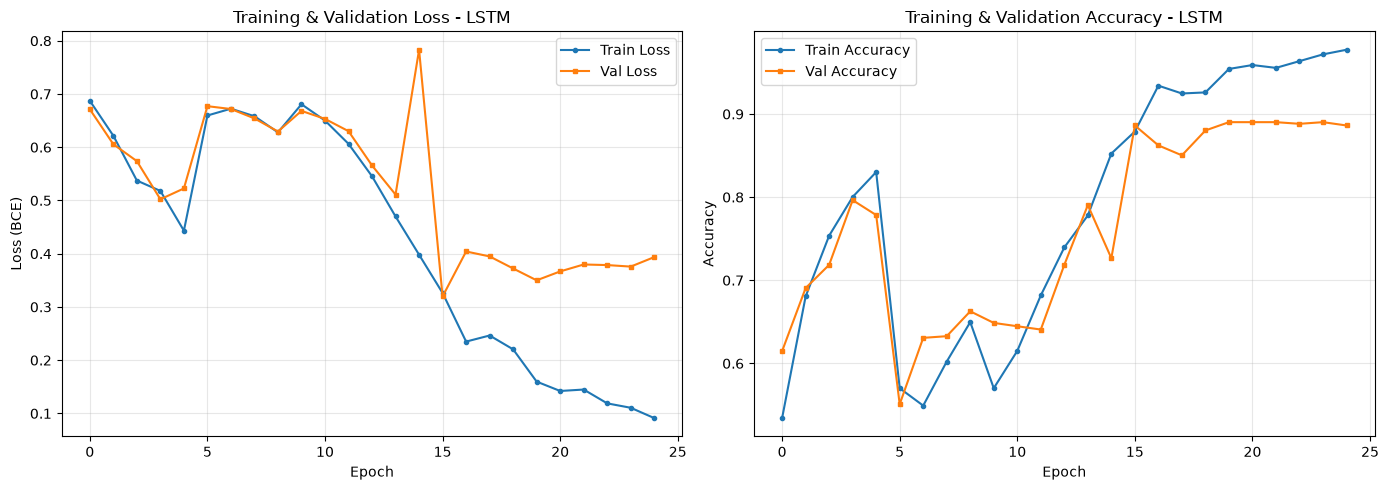

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', marker='o', markersize=3)
axes[0].plot(val_losses, label='Val Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Training & Validation Loss - LSTM')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accuracies, label='Train Accuracy', marker='o', markersize=3)
axes[1].plot(val_accuracies, label='Val Accuracy', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy - LSTM')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(y_batch.numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)

print('=' * 50)
print('         KẾT QUẢ ĐÁNH GIÁ - LSTM')
print('=' * 50)
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print('=' * 50)
print('\nConfusion Matrix:')
print(confusion_matrix(test_labels, test_preds))
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=['Tin thật (0)', 'Tin giả (1)']))

         KẾT QUẢ ĐÁNH GIÁ - LSTM
Accuracy:  0.9042
Precision: 0.9519
Recall:    0.8907
F1-Score:  0.9203

Confusion Matrix:
[[176  14]
 [ 34 277]]

Classification Report:
              precision    recall  f1-score   support

Tin thật (0)       0.84      0.93      0.88       190
 Tin giả (1)       0.95      0.89      0.92       311

    accuracy                           0.90       501
   macro avg       0.89      0.91      0.90       501
weighted avg       0.91      0.90      0.90       501



### Dự đoán mẫu thực tế

In [27]:
model.eval()
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 10, replace=False)

print('=' * 80)
print('DỰ ĐOÁN TIN GIẢ TRÊN MẪU THỰC TẾ - LSTM')
print('=' * 80)
print(f'{"Mẫu":<5} | {"Nhãn thực":<10} | {"Nhãn dự đoán":<12} | {"Xác suất":<10} | {"Kết quả":<8}')
print('-' * 80)

label_map = {0: 'Thật', 1: 'Giả'}
for i, idx in enumerate(sample_indices):
    x_input = torch.tensor([X_test[idx]], dtype=torch.long).to(device)
    with torch.no_grad():
        output = model(x_input)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob >= 0.5 else 0
    actual = int(y_test[idx])
    result = 'Đúng' if pred == actual else 'Sai'
    print(f'{i+1:<5} | {label_map[actual]:<10} | {label_map[pred]:<12} | {prob:.4f}     | {result}')

print('=' * 80)

DỰ ĐOÁN TIN GIẢ TRÊN MẪU THỰC TẾ - LSTM
Mẫu   | Nhãn thực  | Nhãn dự đoán | Xác suất   | Kết quả 
--------------------------------------------------------------------------------
1     | Giả        | Giả          | 0.9951     | Đúng
2     | Thật       | Thật         | 0.0127     | Đúng
3     | Giả        | Giả          | 0.9868     | Đúng
4     | Thật       | Thật         | 0.0113     | Đúng
5     | Thật       | Thật         | 0.0541     | Đúng
6     | Giả        | Giả          | 0.9833     | Đúng
7     | Giả        | Giả          | 0.5463     | Đúng
8     | Thật       | Thật         | 0.0075     | Đúng
9     | Giả        | Thật         | 0.1221     | Sai
10    | Giả        | Giả          | 0.9659     | Đúng


In [28]:
sample_idx = len(X_test) - 1
x_input = torch.tensor([X_test[sample_idx]], dtype=torch.long).to(device)

with torch.no_grad():
    output = model(x_input)
    prob = torch.sigmoid(output).item()
    pred = 1 if prob >= 0.5 else 0

actual = int(y_test[sample_idx])
label_map = {0: 'Thật', 1: 'Giả'}

print('\n' + '=' * 60)
print('CHI TIẾT MẪU DỰ ĐOÁN - LSTM')
print('=' * 60)
print(f'Nhãn thực tế:   {label_map[actual]} ({actual})')
print(f'Nhãn dự đoán:   {label_map[pred]} ({pred})')
print(f'Xác suất tin giả: {prob:.4f}')
print(f'Chênh lệch:     {abs(prob - actual):.4f}')
print(f'Kết quả:        {"ĐÚNG" if pred == actual else "SAI"}')
print('=' * 60)


CHI TIẾT MẪU DỰ ĐOÁN - LSTM
Nhãn thực tế:   Giả (1)
Nhãn dự đoán:   Giả (1)
Xác suất tin giả: 0.9785
Chênh lệch:     0.0215
Kết quả:        ĐÚNG
